# Methodological Appendix: Hierarchical Bayesian Model (Temperature–Mortality)

## Data and notation
Each row is an observation \(i\) for a country \(j\) and year \(t\).

- Outcome: \(y_i\) = `deaths_per_100k`
- Exposure: \(x_i\) = `temperature` (°C)
- Grouping: \(j[i]\) indexes the country of observation \(i\)

## Likelihood
We model the observed mortality rate with a Normal likelihood:

$$
y_i \sim \mathcal{N}(\mu_i,\ \sigma_{\text{obs}})
$$

## Mean structure (log-link, as implemented)
The expected mortality rate is modeled with a log-linear mean and exponential link:

$$
\log(\mu_i) = \alpha + \beta_{j[i]} \, x_i
\quad\Longleftrightarrow\quad
\mu_i = \exp\!\left(\alpha + \beta_{j[i]} x_i\right)
$$

## Hierarchical prior (partial pooling)
Country-specific temperature effects share information via a population distribution:

$$
\beta_j \sim \mathcal{N}(\mu_\beta,\ \sigma_\beta)
$$

Priors (as implemented in the notebook):

$$
\alpha \sim \mathcal{N}(0,10),\quad
\mu_\beta \sim \mathcal{N}(0,1),\quad
\sigma_\beta \sim \text{HalfNormal}(1),\quad
\sigma_{\text{obs}} \sim \text{HalfNormal}(10)
$$

## Inference
Posterior inference uses MCMC with the No-U-Turn Sampler (NUTS) in PyMC:

- draws = 500
- tuning = 500

## Interpretation (association, not causal)
\(\beta_j\) is the country-specific temperature–mortality association on the **log scale**.
A 1°C increase changes the expected mortality multiplicatively by:

$$
\frac{\mu(x+1)}{\mu(x)} = \exp(\beta_j)
$$

Example: if \(\beta_j=0.02\), then \(\exp(0.02)\approx 1.02\) (≈2% higher expected mortality per +1°C).

This is a **proxy demonstration** of hierarchical modeling infrastructure; causal interpretation would require additional design and confounder control.


Libraries loaded successfully.
Health Data Loaded: 240 rows.
Weather Data Loaded: 30 rows.
Merged Dataset Shape: (240, 6)
Merge successful. Preview:
   country  year  deaths_per_100k  deaths_upper  deaths_lower  temperature
0  Finland  1994      6745.118370   7184.164975   5779.353881     1.916392
1  Finland  1994       451.239299    469.757926    414.136077     1.916392
2  Finland  1993      7062.068766   7538.847411   6075.807761     1.801168
3  Finland  1993       474.810196    492.635587    437.067912     1.801168
4  Finland  1992      6962.323809   7418.255273   5999.525199     2.861445

Initializing PyMC Model... (This uses probabilistic programming)
Starting MCMC Sampling... (Please wait 30-60 seconds)


Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [alpha, mu_beta, sigma_beta, beta, sigma_obs]


Output()

Sampling 4 chains for 500 tune and 500 draw iterations (2_000 + 2_000 draws total) took 836 seconds.
There were 4 divergences after tuning. Increase `target_accept` or reparameterize.


Sampling complete.

Generating Forest Plot...


<Figure size 1000x600 with 0 Axes>

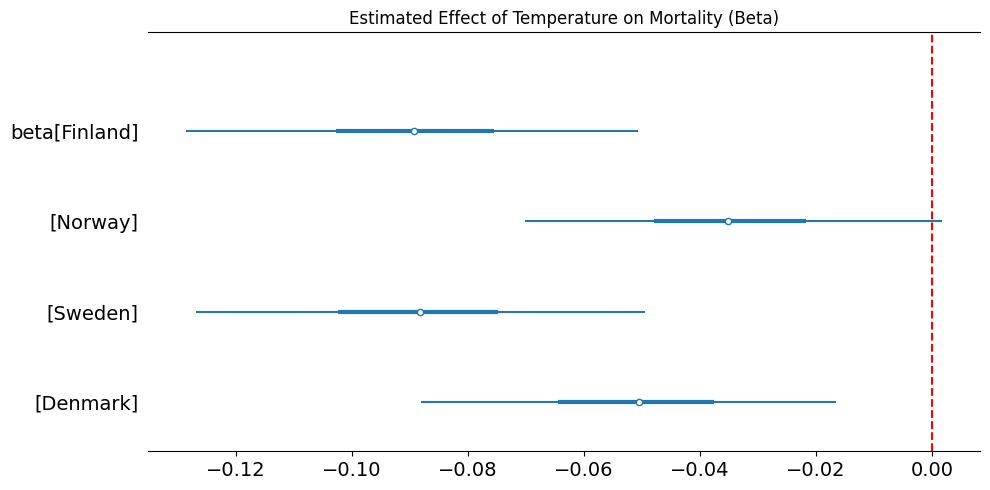


Interpretation:
If the dots are to the right of the red line, higher temperatures are associated with higher mortality.


In [3]:
# notebooks/02_mortality_model.ipynb

# --- 0. Setup & Config ---
# This magic command ensures graphs appear INSIDE the notebook
%matplotlib inline 

import pymc as pm
import arviz as az
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries loaded successfully.")

# --- 1. Load the Data ---
# We load the two datasets we processed in the previous steps
try:
    df_health = pd.read_csv('../data/processed/gbd_clean_nordic.csv')
    df_weather = pd.read_csv('../data/processed/norway_weather_clean.csv')
    print(f"Health Data Loaded: {df_health.shape[0]} rows.")
    print(f"Weather Data Loaded: {df_weather.shape[0]} rows.")
except FileNotFoundError as e:
    print(f"CRITICAL ERROR: Data file not found. {e}")
    print("Stop here and check your 'data/processed' folder.")
    raise

# --- 2. Merge the Data ---
# We merge on 'year'.
df_merged = pd.merge(df_health, df_weather, on='year', how='inner')

print(f"Merged Dataset Shape: {df_merged.shape}")

# SAFETY CHECK: Did the merge fail?
if df_merged.empty:
    print("\nERROR: The merged dataset is empty!")
    print("Check: Do both CSVs have a 'year' column with matching numbers (e.g., 1990, 1991)?")
    print(f"Health Years: {df_health['year'].unique()[:5]}...")
    print(f"Weather Years: {df_weather['year'].unique()[:5]}...")
    # Stop execution if empty
    raise ValueError("Merged data is empty. Cannot proceed with modeling.")
else:
    print("Merge successful. Preview:")
    print(df_merged.head())

# --- 3. The Bayesian Model ---
print("\nInitializing PyMC Model... (This uses probabilistic programming)")

coords = {
    "country": df_merged['country'].unique(),
    "obs_id": np.arange(len(df_merged))
}

with pm.Model(coords=coords) as hierarchical_model:
    # --- Data Containers ---
    # Convert inputs to simple numpy arrays to avoid indexing errors
    temp_values = df_merged['temperature'].values
    # Create integer codes for countries (0, 1, 2, 3...)
    country_codes = pd.Categorical(df_merged['country']).codes
    deaths_observed = df_merged['deaths_per_100k'].values
    
    # --- Priors ---
    # Intercept (Baseline death rate)
    alpha = pm.Normal("alpha", mu=0, sigma=10)
    
    # Slope (Effect of Temperature): Hierarchical Prior
    mu_beta = pm.Normal("mu_beta", mu=0, sigma=1)
    sigma_beta = pm.HalfNormal("sigma_beta", sigma=1)
    
    # Country-specific slopes
    beta = pm.Normal("beta", mu=mu_beta, sigma=sigma_beta, dims="country")
    
    # --- Linear Combination (Log Link for Rate) ---
    # Log-linear model: log(Rate) = alpha + beta * Temp
    # We use .flatten() to ensure dimensions match
    mu = pm.math.exp(alpha + beta[country_codes] * temp_values)
    
    # --- Likelihood ---
    # Observed values
    sigma_obs = pm.HalfNormal("sigma_obs", sigma=10)
    y_obs = pm.Normal("y_obs", mu=mu, sigma=sigma_obs, observed=deaths_observed)

    # --- Inference ---
    print("Starting MCMC Sampling... (Please wait 30-60 seconds)")
    # We use fewer chains/samples to make it run faster for the demo
    idata = pm.sample(500, tune=500, return_inferencedata=True, progressbar=True)
    print("Sampling complete.")

# --- 4. Visualization ---
print("\nGenerating Forest Plot...")
plt.figure(figsize=(10, 6))
az.plot_forest(idata, var_names=["beta"], combined=True, figsize=(10, 5))
plt.title("Estimated Effect of Temperature on Mortality (Beta)")
plt.axvline(x=0, color='red', linestyle='--')
plt.tight_layout()
plt.show()

print("\nInterpretation:")
print("If the dots are to the right of the red line, higher temperatures are associated with higher mortality.")